In [121]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import train_test_split
from scipy import stats

In [122]:

data = pd.read_csv('data (1).csv')




In [123]:
print(data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [124]:

print(data.columns)


Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst'],
      dtype='object')


In [125]:
print(data.isnull().sum())


id                         0
diagnosis                  0
radius_mean                0
texture_mean               0
perimeter_mean             0
area_mean                  0
smoothness_mean            0
compactness_mean           0
concavity_mean             0
concave points_mean        0
symmetry_mean              0
fractal_dimension_mean     0
radius_se                  0
texture_se                 0
perimeter_se               0
area_se                    0
smoothness_se              0
compactness_se             0
concavity_se               0
concave points_se          0
symmetry_se                0
fractal_dimension_se       0
radius_worst               0
texture_worst              0
perimeter_worst            0
area_worst                 0
smoothness_worst           0
compactness_worst          0
concavity_worst            0
concave points_worst       0
symmetry_worst             0
fractal_dimension_worst    0
dtype: int64


In [126]:
data.drop(['Unnamed: 32', 'id'], axis=1, inplace=True , errors='ignore')
data['diagnosis'] = data['diagnosis'].map({'M': 1, 'B': 0})

In [127]:
y = data['diagnosis'].values
x_data = data.drop(['diagnosis'], axis=1)

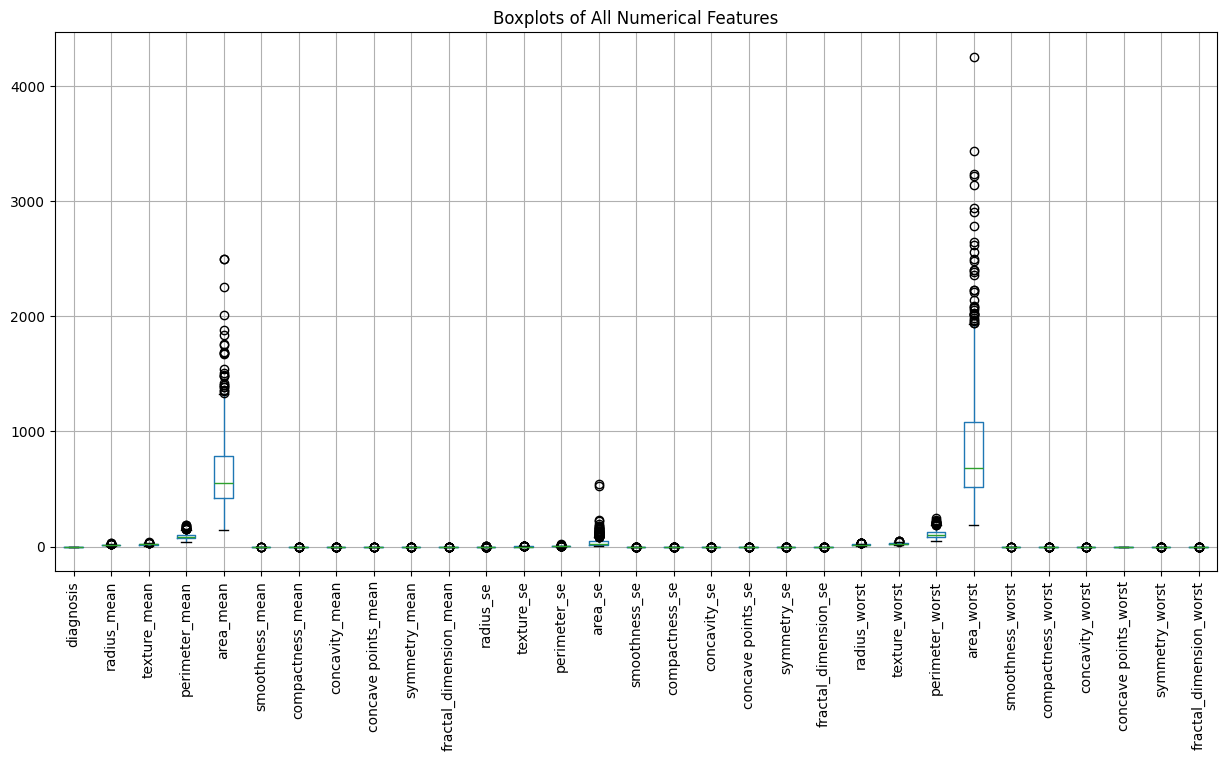

In [128]:
plt.figure(figsize=(15, 7))
data.boxplot()
plt.title("Boxplots of All Numerical Features")
plt.xticks(rotation=90)
plt.show()

Columns chosen for selective standardization: ['area_mean', 'perimeter_mean', 'area_worst', 'perimeter_worst']

 Standardization applied ONLY to selected outlier-heavy columns.



C:\Users\Abdullah Laptop\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


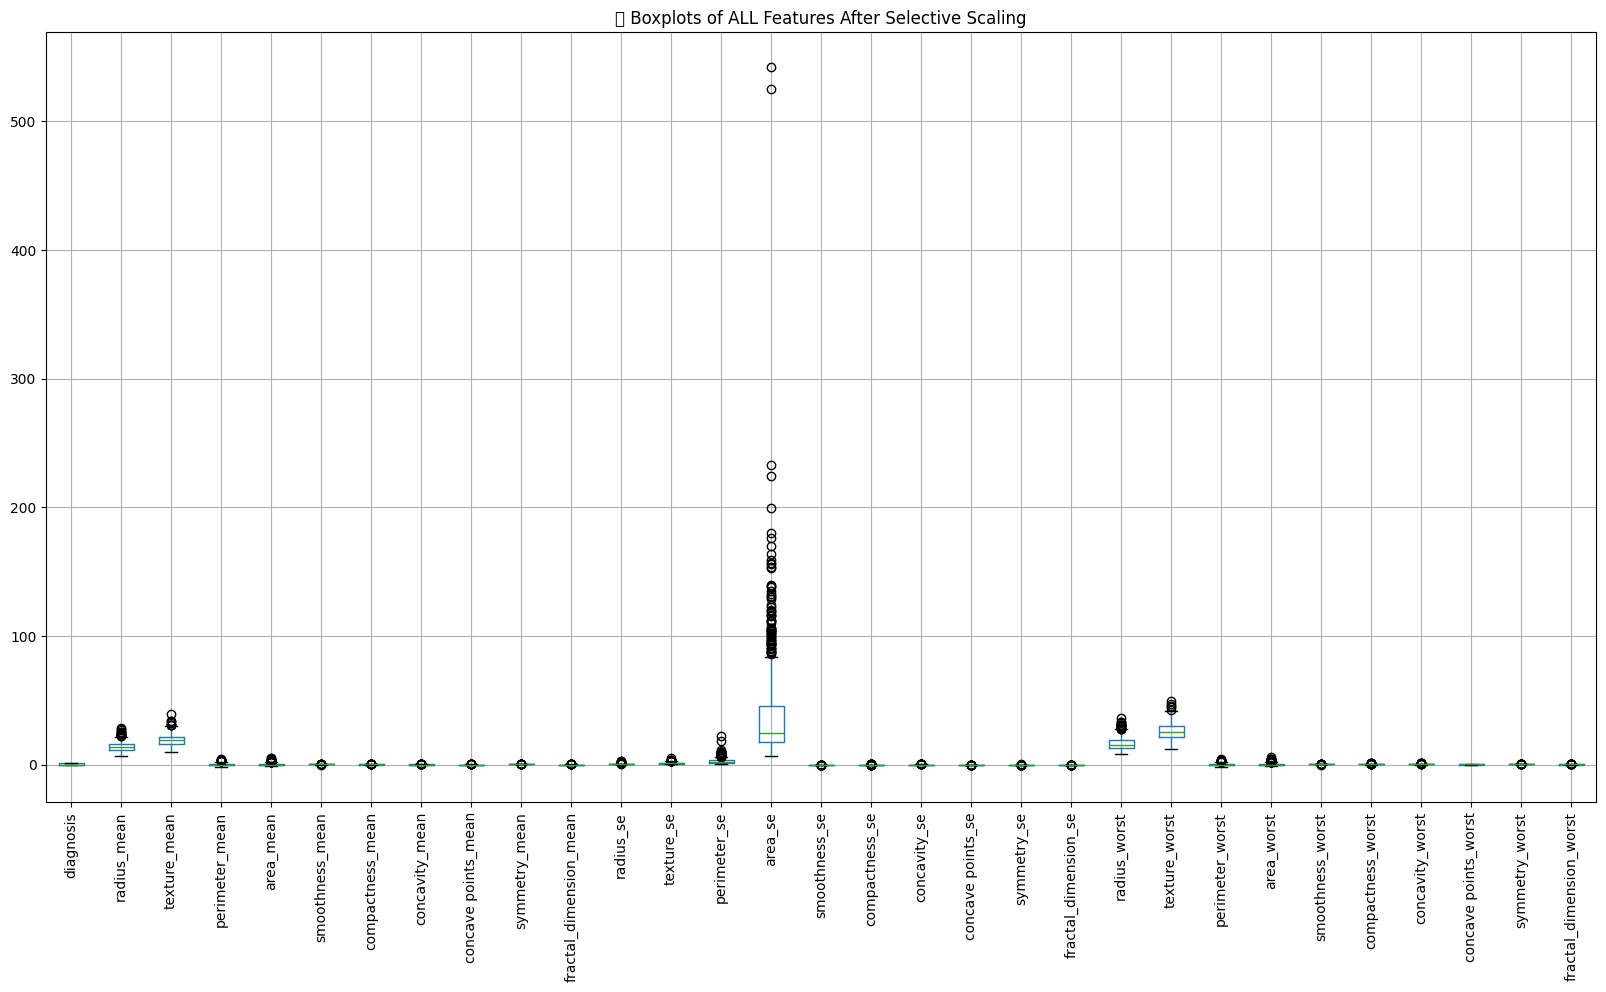

In [129]:
outlier_columns = [
    'area_mean',
    'perimeter_mean',
    'area_worst',
    'perimeter_worst'
]

print("Columns chosen for selective standardization:", outlier_columns)


scaler = StandardScaler()
data_scaled = data.copy()
data_scaled[outlier_columns] = scaler.fit_transform(data[outlier_columns])
print("\n Standardization applied ONLY to selected outlier-heavy columns.\n")


plt.figure(figsize=(20, 10))
data_scaled.boxplot()
plt.title("📉 Boxplots of ALL Features After Selective Scaling")
plt.xticks(rotation=90)
plt.show()

In [130]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


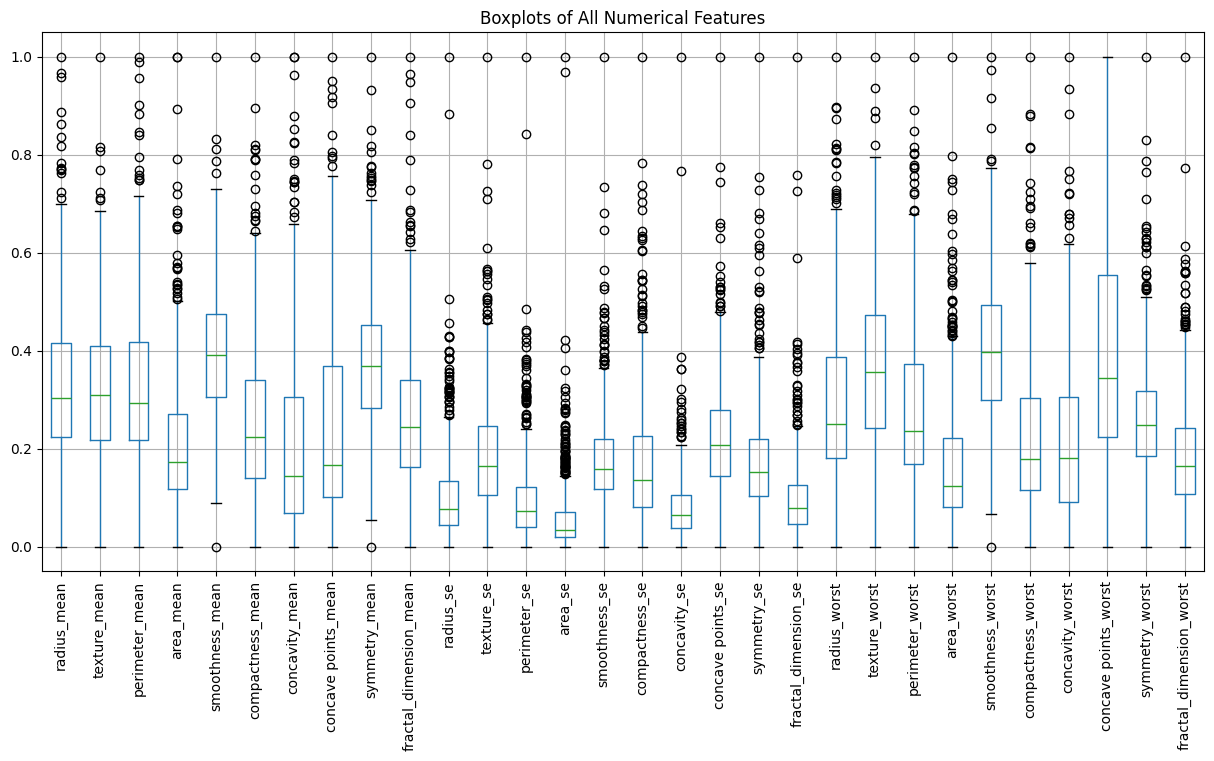

In [131]:
plt.figure(figsize=(15, 7))

x.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

In [132]:
x = (x_data - x_data.min()) / (x_data.max() - x_data.min())
x

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,0.521037,0.022658,0.545989,0.363733,0.593753,0.792037,0.703140,0.731113,0.686364,0.605518,...,0.620776,0.141525,0.668310,0.450698,0.601136,0.619292,0.568610,0.912027,0.598462,0.418864
1,0.643144,0.272574,0.615783,0.501591,0.289880,0.181768,0.203608,0.348757,0.379798,0.141323,...,0.606901,0.303571,0.539818,0.435214,0.347553,0.154563,0.192971,0.639175,0.233590,0.222878
2,0.601496,0.390260,0.595743,0.449417,0.514309,0.431017,0.462512,0.635686,0.509596,0.211247,...,0.556386,0.360075,0.508442,0.374508,0.483590,0.385375,0.359744,0.835052,0.403706,0.213433
3,0.210090,0.360839,0.233501,0.102906,0.811321,0.811361,0.565604,0.522863,0.776263,1.000000,...,0.248310,0.385928,0.241347,0.094008,0.915472,0.814012,0.548642,0.884880,1.000000,0.773711
4,0.629893,0.156578,0.630986,0.489290,0.430351,0.347893,0.463918,0.518390,0.378283,0.186816,...,0.519744,0.123934,0.506948,0.341575,0.437364,0.172415,0.319489,0.558419,0.157500,0.142595
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,0.690000,0.428813,0.678668,0.566490,0.526948,0.296055,0.571462,0.690358,0.336364,0.132056,...,0.623266,0.383262,0.576174,0.452664,0.461137,0.178527,0.328035,0.761512,0.097575,0.105667
565,0.622320,0.626987,0.604036,0.474019,0.407782,0.257714,0.337395,0.486630,0.349495,0.113100,...,0.560655,0.699094,0.520892,0.379915,0.300007,0.159997,0.256789,0.559450,0.198502,0.074315
566,0.455251,0.621238,0.445788,0.303118,0.288165,0.254340,0.216753,0.263519,0.267677,0.137321,...,0.393099,0.589019,0.379949,0.230731,0.282177,0.273705,0.271805,0.487285,0.128721,0.151909
567,0.644564,0.663510,0.665538,0.475716,0.588336,0.790197,0.823336,0.755467,0.675253,0.425442,...,0.633582,0.730277,0.668310,0.402035,0.619626,0.815758,0.749760,0.910653,0.497142,0.452315


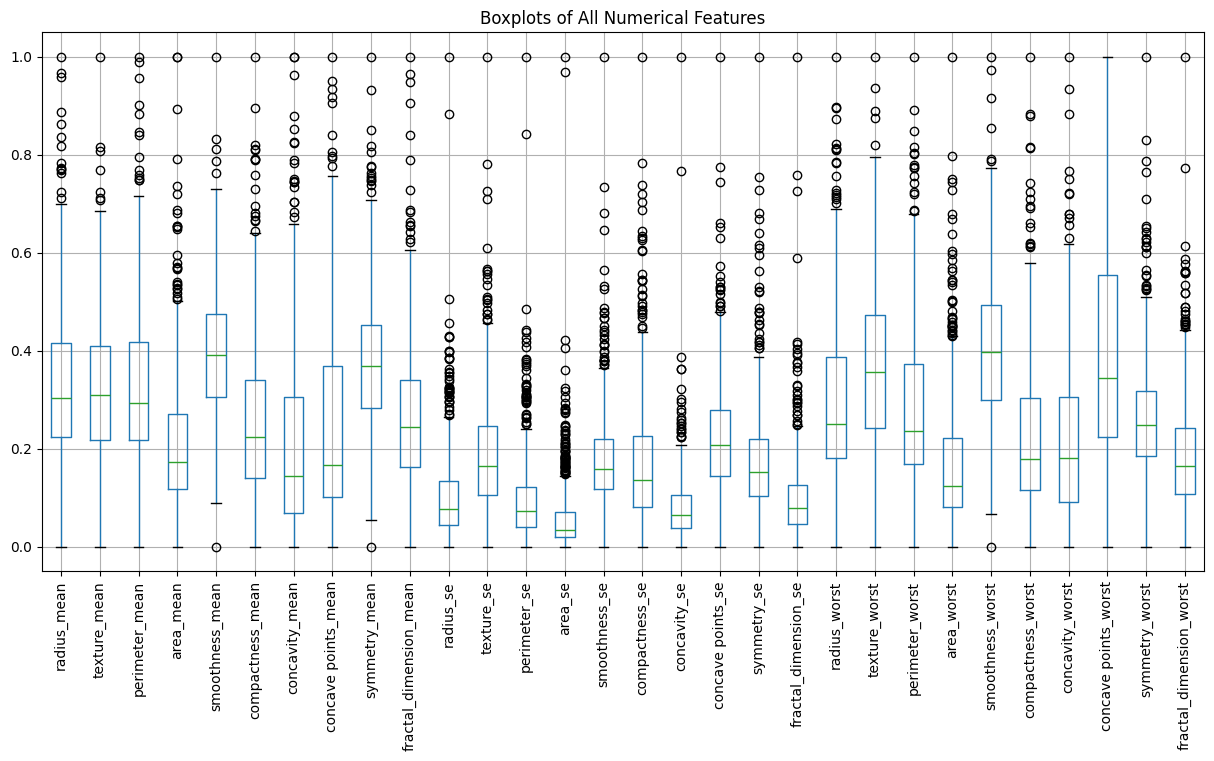

In [133]:
plt.figure(figsize=(15, 7))

x.boxplot(rot=90)
plt.title("Boxplots of All Numerical Features")
plt.show()

In [134]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = data.drop('diagnosis', axis=1).columns
data_scaled = data.copy()
data_scaled[numeric_cols] = scaler.fit_transform(data_scaled[numeric_cols])


In [135]:
from sklearn.model_selection import train_test_split

train_data, temp_data = train_test_split(
    data_scaled,
    train_size=0.30,  
    random_state=42,
    stratify=data_scaled['diagnosis']
)


test1_data, test2_data = train_test_split(
    temp_data,
    train_size=0.5, 
    test_size=0.5,   
    random_state=42,
    stratify=temp_data['diagnosis']
)

print(f"Train: {train_data.shape}, Test1: {test1_data.shape}, Test2: {test2_data.shape}")

def separate_features_labels(df):
    X = df.drop('diagnosis', axis=1).values
    y = df['diagnosis'].values.reshape(-1,1)
    return X, y

X_train, y_train = separate_features_labels(train_data)
X_test1, y_test1 = separate_features_labels(test1_data)
X_test2, y_test2 = separate_features_labels(test2_data)



X_train_bias = np.c_[np.ones((X_train.shape[0],1)), X_train]
X_test1_bias = np.c_[np.ones((X_test1.shape[0],1)), X_test1]
X_test2_bias = np.c_[np.ones((X_test2.shape[0],1)), X_test2]


Train: (170, 31), Test1: (199, 31), Test2: (200, 31)


In [136]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [137]:
from sklearn.model_selection import StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


In [ ]:
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
k_range = range(2, 16) 

cv_results = {'K': [], 'Accuracy': [], 'Precision': [], 'Recall': [], 'F1': []}

for k in k_range:
    acc_scores, prec_scores, rec_scores, f1_scores = [], [], [], []
    
    for train_idx, val_idx in kf.split(X_train, y_train):
        X_tr, X_val = X_train[train_idx], X_train[val_idx]
        y_tr, y_val = y_train[train_idx], y_train[val_idx]

        
        knn = KNeighborsClassifier(n_neighbors=k, weights='distance', metric='manhattan')
        knn.fit(X_tr, y_tr.ravel())
        y_pred = knn.predict(X_val)
        
        acc_scores.append(accuracy_score(y_val, y_pred))
        prec_scores.append(precision_score(y_val, y_pred))
        rec_scores.append(recall_score(y_val, y_pred))
        f1_scores.append(f1_score(y_val, y_pred))
    
    
    cv_results['K'].append(k)
    cv_results['Accuracy'].append(np.mean(acc_scores))
    cv_results['Precision'].append(np.mean(prec_scores))
    cv_results['Recall'].append(np.mean(rec_scores))
    cv_results['F1'].append(np.mean(f1_scores))

cv_df = pd.DataFrame(cv_results)
print(" Cross-Validation Results:")
display(cv_df)


📊 Cross-Validation Results:


,K,Accuracy,Precision,Recall,F1
0,2,0.941176,0.953846,0.889744,0.918382
1,3,0.958824,0.981818,0.905128,0.940485
2,4,0.958824,0.981818,0.905128,0.940485
3,5,0.941176,1.000000,0.838462,0.904586
4,6,0.952941,1.000000,0.871795,0.928646
5,7,0.935294,1.000000,0.821795,0.897342
6,8,0.935294,1.000000,0.821795,0.897342
7,9,0.935294,1.000000,0.821795,0.897342
8,10,0.935294,1.000000,0.821795,0.897342
9,11,0.935294,1.000000,0.821795,0.897342


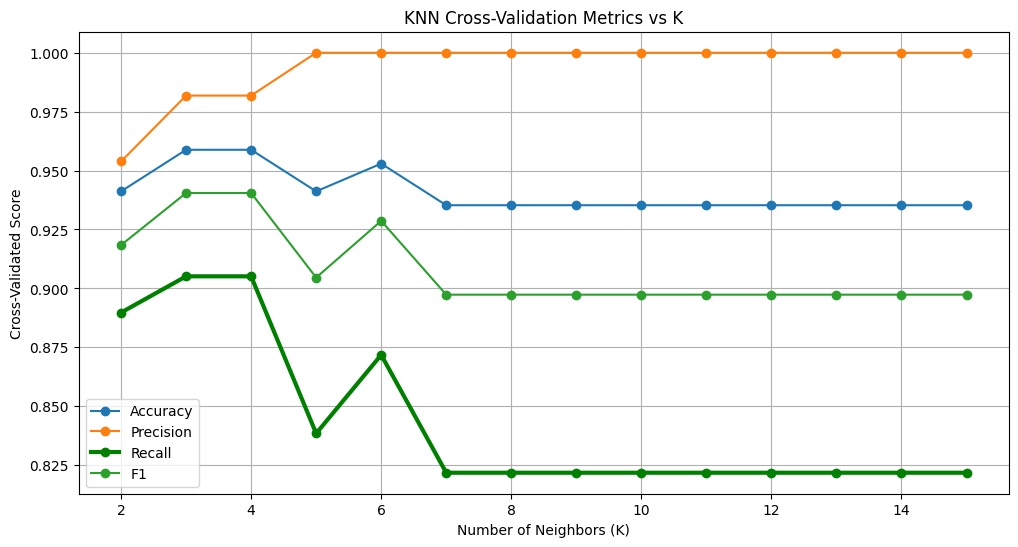

In [139]:
plt.figure(figsize=(12,6))
plt.plot(cv_df['K'], cv_df['Accuracy'], marker='o', label='Accuracy')
plt.plot(cv_df['K'], cv_df['Precision'], marker='o', label='Precision')
plt.plot(cv_df['K'], cv_df['Recall'], marker='o', label='Recall', color='green', linewidth=3)
plt.plot(cv_df['K'], cv_df['F1'], marker='o', label='F1')
plt.xlabel('Number of Neighbors (K)')
plt.ylabel('Cross-Validated Score')
plt.title('KNN Cross-Validation Metrics vs K')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
best_k = cv_df.loc[cv_df['Recall'].idxmax(), 'K']
best_recall = cv_df['Recall'].max()
print(f" Best K based on Recall: {best_k} (Mean Recall = {best_recall:.4f})")


✅ Best K based on Recall: 3 (Mean Recall = 0.9051)



📊 Metrics for Training Set:
Accuracy:  1.0000
Precision: 1.0000
Recall:    1.0000
F1 Score:  1.0000


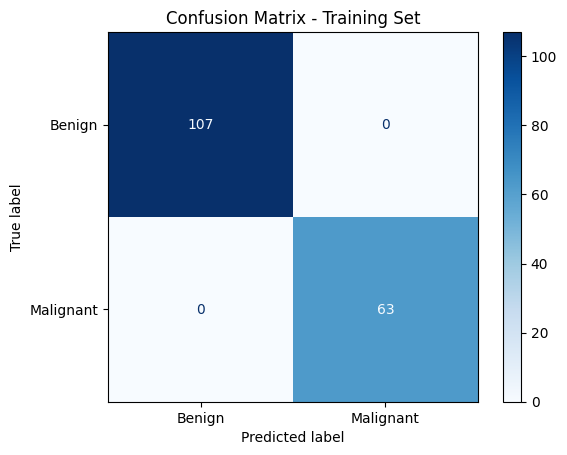


📊 Metrics for Test1 Set:
Accuracy:  0.9548
Precision: 0.9851
Recall:    0.8919
F1 Score:  0.9362


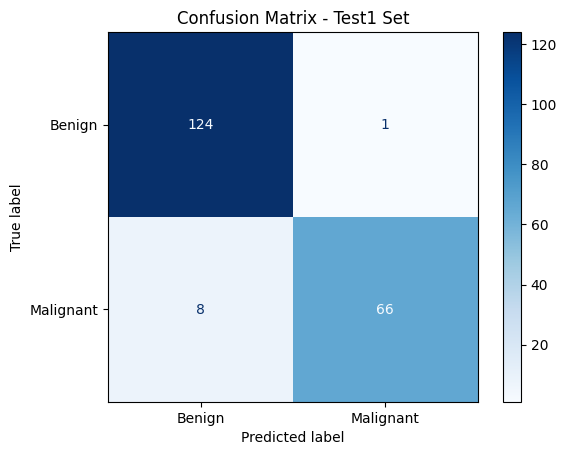


📊 Metrics for Test2 Set:
Accuracy:  0.9400
Precision: 0.9846
Recall:    0.8533
F1 Score:  0.9143


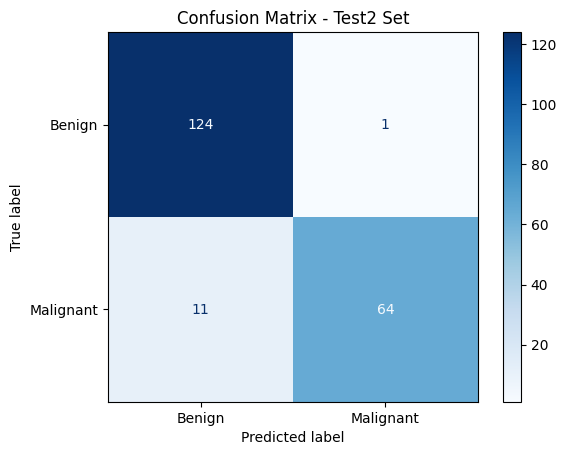

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

def evaluate_knn(model, X, y, dataset_name="Dataset"):
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    prec = precision_score(y, y_pred)
    rec = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    
    print(f"\n Metrics for {dataset_name}:")
    print(f"Accuracy:  {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall:    {rec:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    
    cm = confusion_matrix(y, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f"Confusion Matrix - {dataset_name}")
    plt.show()
    
    return acc, prec, rec, f1

best_knn = KNeighborsClassifier(n_neighbors=best_k, weights='distance', metric='manhattan')
best_knn.fit(X_train, y_train.ravel())

train_metrics = evaluate_knn(best_knn, X_train, y_train, "Training Set")
test1_metrics = evaluate_knn(best_knn, X_test1, y_test1, "Test1 Set")
test2_metrics = evaluate_knn(best_knn, X_test2, y_test2, "Test2 Set")
